**Proyecto I – Parte III (Core)

Análisis y Predicción de Ventas en una Tienda de Retail (Core)**

*Parte III: Transformación y Análisis Avanzado de Datos con Pandas*


- En esta tercera parte del proyecto, continuaremos trabajando con el dataset de ventas que utilizamos en la Parte II.

- En esta fase, aplicaremos técnicas avanzadas de transformación y análisis de datos utilizando las nuevas habilidades adquiridas en Pandas, tales como agrupaciones complejas y el uso del método apply. Nos enfocaremos en extraer insights más profundos y preparar los datos para futuros análisis y modelos predictivos.



1. Transformación de Datos

- Crea nuevas columnas: Basándonos en los datos existentes, crea nuevas columnas que sean útiles para el análisis. Por ejemplo, calcula el ingreso total por venta y normaliza las ventas.

- Clasifica los datos: Crea una columna que clasifique las ventas en categorías significativas (e.g., ‘Alta’, ‘Media’, ‘Baja’).

Consideraciones *Desarrollo y resumen de cada punto se desarrollan con apoyo de IA Gen.
- La estructura busca responder al encargo pero también a dejar insights de estudio posterior*

In [ ]:
# _______________________________________
#   Creación del entorno de ejecición:
# _______________________________________

# Inicio importando pandas para poder trabajar con tablas de datos
#  numpy para hacer operaciones numéricas que solicita el enunciado.
# display para ver mejor los resultados en colab
import pandas as pd
import numpy as np
from IPython.display import display


# _________________________________________
#             Carga DataSet
# __________________________________________

# Se carga el archivo CSV desde Googledrive.
df = pd.read_csv('/content/drive/MyDrive/Ejercicios Core/retail_sales_dataset.csv')


# _______________________________________________________________
#         creación de nuevas columnas y normalización de ventas
#_________________________________________________________________

# creo una nueva columna llamada "Ingreso_total" solo como validación,
# MOTIVO: la columna "Total Amount" ya contiene ese valor en el dataset.
#**motivo de realizar esto**: lo dejare solo como ejercicio de "verificar que el total coincida con Quantity * Price per Unit.

df['Ingreso_Total'] = df['Quantity'] * df['Price per Unit'] # Calculo el ingreso total de cada venta multiplicando la cantidad por el precio unitario.

max_ventas = df['Total Amount'].max() # buscoel valor máximo de la columna -Total Amount-

# busco el valor mínimo de la columna "Total Amount".
min_ventas = df['Total Amount'].min()

#============================================
# Continuo con la crración de nueva columna: "Ventas_normalizadas".
# Uso apply() para "recorrer" cada valor de "Total Amount" y aplicar "fórmula" de normalización.
# esta fórmula lo que hace es restar el valor mínimo y divide por la diferencia entre el máximo y el mínimo.
df['Ventas_normalizadas'] = df['Total Amount'].apply(lambda x: (x - min_ventas) / (max_ventas - min_ventas)
)
#============================================================
# Muestro las primeras filas para revisar que todo quedó bien.
#============================================================
display(df[['Total Amount', 'Ingreso_Total', 'Ventas_normalizadas']].head())


,Total Amount,Ingreso_Total,Ventas_normalizadas
0,150,150,0.063291
1,1000,1000,0.493671
2,30,30,0.002532
3,500,500,0.240506
4,100,100,0.037975


Resúmen del punto 1:

 **Explicación del proceso realizado:**  
 En esta etapa se trabajó con Pandas para practicar transformación de datos y creación de nuevas columnas, tal como se revisó en clases.  

Primero, se creó la columna -Ingreso_Total- multiplicando -Quantity * Price per Unit. (Aunque el dataset ya contiene la columna `-total Amount, este cálculo se realizó como ejercicio práctico para comprender cómo generar nuevas variables a partir de columnas existentes y verificar que los valores coincidieran correctamente.  

Posteriormente, se aplicó una normalización sobre la columna Total Amount. La normalización consiste en llevar los datos a una escala común entre 0 y 1 utilizando la fórmula:

==(valor - mínimo) / (máximo - mínimo)==

ejemplo:
- Si una venta es de $ 50 y la otra es de ($ 2000:

$50 representa el extremo más bajo

$2000 representa el extremo más alto

Después de normalizar, ambas quedan en una escala común, y eso permite decir cuál es más baja o más alta de forma proporcional.

- Razón de la importancia: permite comparar ventas grandes y pequeñas sin que las grandes “taparan” a las pequeñas.

 Para realizar esta transformación se utilizó apply() junto a lambda, lo que permitió "recorrer" cada valor individual de la columna y aplicarle la fórmula de normalización.  

 Finalmente, se utilizó display()` para visualizar los resultados de forma más clara en Google Colab, mostrando únicamente las columnas relevantes para revisar las transformaciones realizadas.

 **2. Agrupación y Agregación
Agrupación por múltiples columnas:a**


- Realiza agrupaciones por categorías como producto y tienda, producto y mes, etc.

- Aplicar funciones de agregación: Utiliza funciones como sum, mean, count, min, max, std, y var para obtener estadísticas descriptivas de cada grupo.

In [ ]:
#___________________________________________
#      2. Agregación y agrupación de datos
#_______________________________________________
# En esta etapa se trabaja con groupby(),
# se agrupan los registros y luego se calculan estadísticas para cada grupo:

# ____________________________________
#         **Creación Columna MES**
#______________________________________________
# Primero se deebe convertir la columna 'Date' a formato fecha.

df['Date'] = pd.to_datetime(df['Date'])

# Luego creo una nueva columna: 'Mes'aplicando dt.month que extrae solo el número del mes
#(proceso similar al que realicé cuando extraje año de emisión de OC en Core7)
# Ejemplo para este caso particular:
# 2023-11-24 ; mes 11
df['Mes'] = df['Date'].dt.month


#___________________________________________
#       Agrupación (por producto y mes)
#____________________________________________

# En este punto agrupo los datos por dos columnas: 'Product Category' y  'Mes'
# y ahora es cuando aplico funciones de agregación sobre la columna 'Total Amount':

agrupacion_producto_mes = (
    df.groupby(['Product Category', 'Mes'])['Total Amount']
    .agg([
        'sum',    # para la suma total de ventas
        'mean',   # calcular promedio de ventas
        'count',  # muestra la cantidad de registros
        'min',    # valor mínimo
        'max',    # valor máximo
        'std',    # la desviación estándar
        'var'     # y la varianza
    ])
)


#____________________________________________
#     Visualización de los resultados obtenidos:
# ==========================================

# Con esto muestro las primeras filas del resultadopara revisar las estadísticas obtenidas
# por categoría de producto y mes.
display(agrupacion_producto_mes.head(10))

sum        mean  count  min   max         std  \
Product Category Mes                                                    
Beauty           1    13930  535.769231     26   25  2000  658.818173   
                 2    14035  539.807692     26   25  2000  697.754227   
                 3    10545  502.142857     21   25  1500  482.914515   
                 4    11905  410.517241     29   25  2000  519.650200   
                 5    12450  444.642857     28   30  2000  571.555591   
                 6    10995  439.800000     25   25  2000  512.246848   
                 7    16090  595.925926     27   30  2000  626.063767   
                 8     9790  407.916667     24   25  1200  451.730770   
                 9     6320  316.000000     20   25  2000  505.963385   
                 10   15355  495.322581     31   25  2000  552.575689   

                                var  
Product Category Mes                 
Beauty           1    434041.384615  
                 2    486860.961538  
                 3    233206.428571  
                 4    270036.330049  
                 5    326675.793651  
                 6    262396.833333  
                 7    391955.840456  
                 8    204060.688406  
                 9    255998.947368  
                 10   305339.892473

Resúmen del punto 2:

Antes de realizar la agrupación, primero fue necesario transformar la columna Date a formato fecha utilizando pd.to_datetime(). Esto se realiza porque originalmente Pandas interpreta las fechas como texto, y mientras una columna sea texto no es posible extraer componentes específicos como el mes, el año o el día.

Posteriormente, se crea una nueva columna llamada Mes utilizando .dt.month, lo que permite extraer únicamente el número del mes desde cada fecha del dataset.

La creación de esta columna es importante porque posteriormente permite realizar agrupaciones temporales y analizar cómo se comportan las ventas según el mes.

Al trabajar con groupby() en Pandas, se logra  separar la tabla original en pequeños grupos según ciertas categorías.

 Para el caso de este dataset los grupos se crean utilizando las columnas Product Category y Mes. Esto significa que Pandas
 - (1) primero organiza los registros por categoría de producto (Beauty, Clothing, Electronics) y (2) luego, dentro de cada categoría, los organiza por mes (1, 2, 3, etc.).

 *Como la agrupación queda ordenada alfabéticamente por Product Category, primero aparece Beauty, y dentro de esa categoría se muestran todos sus meses en orden. Por eso, cuando se utiliza head(10), solamente alcanzan a visualizarse los primeros registros correspondientes a Beauty, antes de llegar a las categorías Clothing y Electronics.


  Posteriormente, se utiliza .agg() para aplicar múltiples funciones de agregación sobre la columna Total Amount.
  
  Estas funciones permiten obtener estadísticas descriptivas para cada grupo generado.
  
  Por ejemplo:
  
  - sum calcula la suma total de ventas.
  - mean calcula el promedio de ventas.
  - count muestra la cantidad de registros. - min identifica el valor mínimo.
  - max identifica el valor máximo.
  - std calcula la desviación estándar.
  - var calcula la varianza.
   
  Para el caso del dataset se materializa así:

  Por ejemplo, el grupo Beauty - Mes 1 representa todas las ventas de productos de belleza realizadas durante enero, mientras que Electronics - Mes 5 representa todas las ventas de productos electrónicos realizadas durante mayo.
  
  Importancia: La principal ventaja de utilizar groupby() es que evita tener que recorrer manualmente el dataset utilizando ciclos for, ya que Pandas realiza automáticamente la separación de grupos y el cálculo de estadísticas de forma eficiente y estructurada.
  
  En resumen: groupby() permite separar los datos en grupos. .agg() permite aplicar cálculos estadísticos sobre cada grupo. head() solo muestra una parte del resultado para facilitar una revisión rápida de la información.

**3. Análisis Personalizado con apply**

- Función personalizada: Aplica funciones personalizadas para realizar análisis específicos que no se pueden lograr con las funciones de agregación estándar.

- Ejemplo de uso avanzado: Calcula la desviación de cada venta respecto a la media de su grupo.


In [ ]:
# ___________________________________________
# Análisis personalziado utilizando función APPLY()
# ___________________________________________

# en este punto de opta por utilizar apply() para realizar un análisis personalizado
#ya que no es posible realizarlo con las funciones estándar usadas previamente
# - sum(), mean() o count() -
#MOTIVO:
# Servirá para calcular cuánto se aleja cada venta respecto del promedio de su grupo.

# ______________________________________________
# primer paso: calcular el promedio por categoría
# ________________________________________________

# (1) se calcula el promedio de ventas para cada categoría de producto.
#Para esto se recurre a transform('mean') ya que permite:
# asignar el promedio correspondiente a cada fila del dataframe.
# En otras palabras: cada venta "recibirá" el promedio de su propia categoría.

df['Promedio_Categoria'] = (
    df.groupby('Product Category')['Total Amount']
    .transform('mean')
)

#______________________
# (2) ejecución "Función Personalizada"
# _____________________

# El objeitvo es crear una función personalizada que permita:
# **calcular la desviación de cada venta respecto al promedio de su categoría**
# Fórmula: venta individual - promedio de la categoría
#De este modo si el resultado:
# - es positivo: la venta está sobre el promedio.
# - si es negativo: la venta está bajo el promedio.
# -pero si es cercano a cero: "la venta está cercana al promedio"

def calcular_desviacion(fila):

    return (
        fila['Total Amount']
        - fila['Promedio_Categoria']
    )


# ____________________________________
# (3) aplicación de la función con APPLY()
#_______________________________________

# En este punto se agrega apply(axis=1) ya que permite "recorrer" fila por fila-
# Es decir , en cada fila:
# 1. se toma Total Amount
#2.  se toma Promedio_Categoria
# 3. se calcula la diferencia entre ambos.

df['Desviacion_Respecto_Media'] = (
    df.apply(calcular_desviacion, axis=1)
)


# ________________________________________
# VISUALIZACIÓN DE RESULTADOS
#_________________________________________

display(
    df[[
        'Product Category',
        'Total Amount',
        'Promedio_Categoria',
        'Desviacion_Respecto_Media'
    ]]
    .head(10)
)

,Product Category,Total Amount,Promedio_Categoria,Desviacion_Respecto_Media
0,Beauty,150,467.475570,-317.475570
1,Clothing,1000,443.247863,556.752137
2,Electronics,30,458.786550,-428.786550
3,Clothing,500,443.247863,56.752137
4,Beauty,100,467.475570,-367.475570
5,Beauty,30,467.475570,-437.475570
6,Clothing,50,443.247863,-393.247863
7,Electronics,100,458.786550,-358.786550
8,Electronics,600,458.786550,141.213450
9,Clothing,200,443.247863,-243.247863


**Resumen punto 3**

Primero se calcula el promedio de ventas de cada categoría de producto usando transform('mean'). Esto permite que cada fila del DataFrame conserve asociado el promedio de su propia categoría, como Beauty, Clothing o Electronics.

Después, se crea una función personalizada para calcular la desviación de cada venta respecto al promedio de su categoría. La fórmula utilizada es:

venta individual - promedio de la categoría.

Luego, se aplica esa función fila por fila con apply(axis=1), lo que permite obtener una nueva columna con la desviación respecto a la media.

Los resultados se interpretan así:

- Si el valor es positivo, la venta está sobre el promedio de su categoría.

- Si el valor es negativo, la venta está bajo el promedio.

- Si el valor es cercano a cero, la venta está cerca del comportamiento promedio del grupo.

**Utilidad práctica**
Este tipo de análisis sirve para detectar ventas atípicas o comportamientos inusuales dentro de cada categoría.

También ayuda a identificar qué productos o categorías están vendiendo más o menos de lo esperado, lo que puede ser útil para decisiones de inventario, promociones, abastecimiento o revisión de registros.

**Ejemplo aplicado**
Por ejemplo, una venta de Electronics con valor 600 tiene desviación positiva porque está sobre el promedio de esa categoría.

En cambio, una venta de Beauty con valor 30 tiene desviación negativa porque está muy por debajo del promedio.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Ejercicios Core/retail_sales_dataset.csv')

**Proyecto** **I** – **Parte** **IV** **(Core)**

> Análisis y Predicción de Ventas en una Tienda de Retail

 Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización*

- En esta cuarta parte del proyecto, aplicaremos técnicas avanzadas de análisis exploratorio de datos (EDA) y visualización para comprender mejor el conjunto de datos de ventas de la tienda de retail.

- Utilizaremos Python, Pandas y Matplotlib para explorar y visualizar los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.



In [ ]:
# __________________________________________
#     Análisis descriptivo básico
# __________________________________________

# En esta etapa se calculan estadísticas descriptivas para comprender mejor el comportamiento general de las variables numéricas del dataset.

# __________________________________________
#     Estadísticas descriptivas generales
# __________________________________________

# describe() calcula automáticamente:
# - count: cantidad de registros
# - mean: promedio
# - std: desviación estándar
# - min: valor mínimo
# - 25%: primer cuartil
# - 50%: mediana
# - 75%: tercer cuartil
# - max: valor máximo

estadisticas = df.describe()

# __________________________________________
#     Visualización de resultados
# __________________________________________

# display() permite visualizar la tabla de forma más ordenada en Google Colab.

display(estadisticas)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


***Hallazgos principales del análisis descriptivo***

**1. Tamaño y calidad del dataset**

- El dataset contiene 1000 registros, ya que la mayoría de las variables numéricas presentan un valor count = 1000.

- Esto indica que no existen datos faltantes relevantes en las columnas numéricas analizadas, lo que facilita el análisis posterior y evita realizar procesos complejos de imputación de datos.

**2. Distribución de la edad de los clientes**

- La edad promedio de los clientes es de aproximadamente 41 años.

- Los valores van desde 18 hasta 64 años, con una desviación estándar cercana a 13 años, lo que sugiere una dispersión moderada en las edades de los clientes y evidencia que no todos pertenecen al mismo rango etario.

**3. Cantidad de productos comprados**

- La cantidad promedio de productos por venta es de aproximadamente 2.5 unidades.

- El valor mínimo es 1 y el máximo es 4, lo que indica que las compras suelen ser pequeñas y relativamente homogéneas, sin grandes diferencias en el volumen de productos adquiridos por transacción.

**4. Precio por unidad (Price per Unit)**

- El precio promedio por unidad es aproximadamente 179.89.

- Sin embargo, la desviación estándar es elevada (≈189.68), lo que indica que existen productos con precios muy distintos entre sí, incluyendo productos económicos y otros de alto valor.

**5. Monto total de la venta (Total Amount)**

- El monto promedio de venta es de aproximadamente 456 unidades monetarias.

- El valor máximo alcanza 2000, mientras que la desviación estándar supera los 559 puntos, lo que evidencia una dispersión importante en los montos de venta y sugiere la posible existencia de ventas atípicas o transacciones de alto valor.

**6. Ventas normalizadas**

- La columna Ventas_normalizadas presenta valores entre 0 y 1, lo que confirma que el proceso de normalización fue aplicado correctamente.

- Esto permite trabajar posteriormente con variables escaladas dentro de un mismo rango, facilitando comparaciones y futuros modelos predictivos.

**7. Variable Mes**

- La columna Mes contiene valores entre 1 y 12, lo que indica que el dataset incluye registros distribuidos a lo largo de todo el año calendario.

- Esto permitirá posteriormente analizar tendencias temporales y posibles patrones estacionales en las ventas.

**8. Desviación respecto a la media**

- La columna Desviacion_Respecto_Media contiene valores positivos y negativos, lo que indica que:

- Algunas ventas se encuentran sobre el promedio de su categoría.
Otras ventas se encuentran bajo el promedio de su categoría.

- Esta variable será útil para detectar comportamientos atípicos, diferencias relevantes entre categorías y posibles patrones de consumo dentro del dataset.

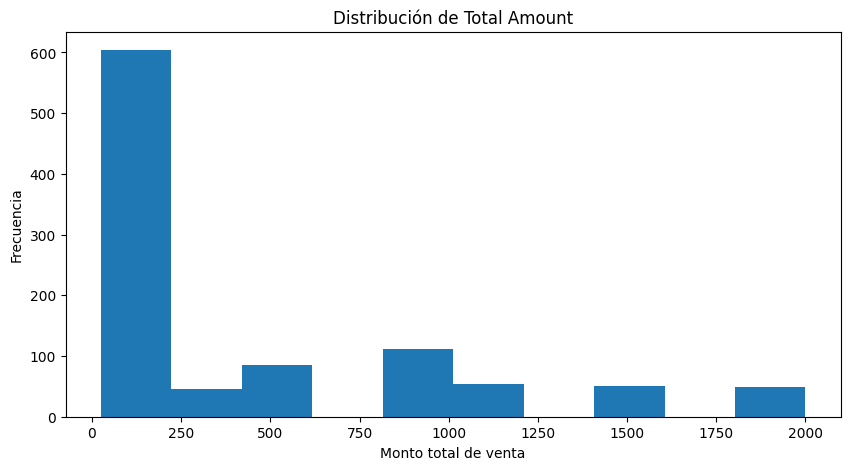

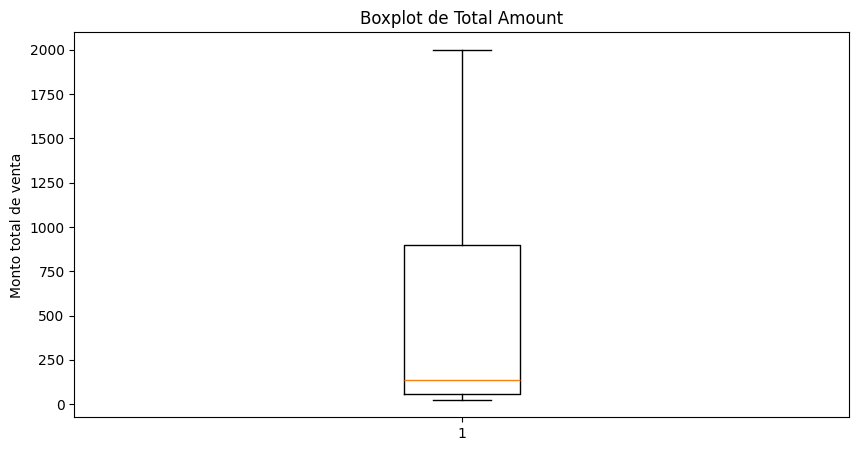

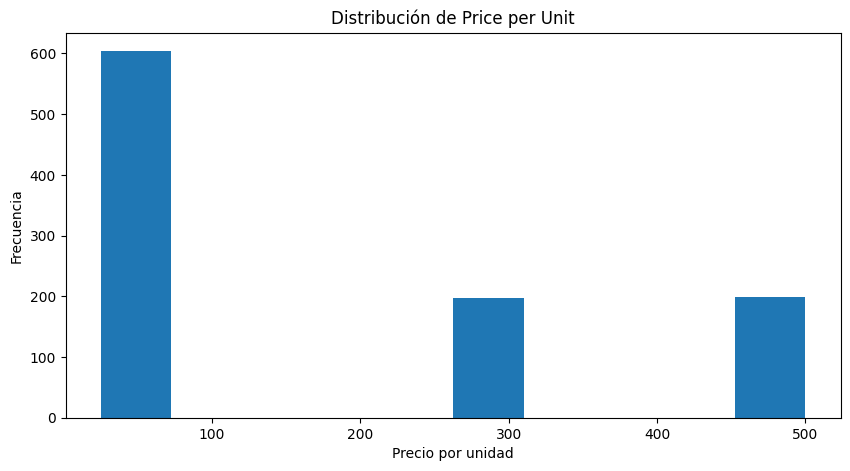

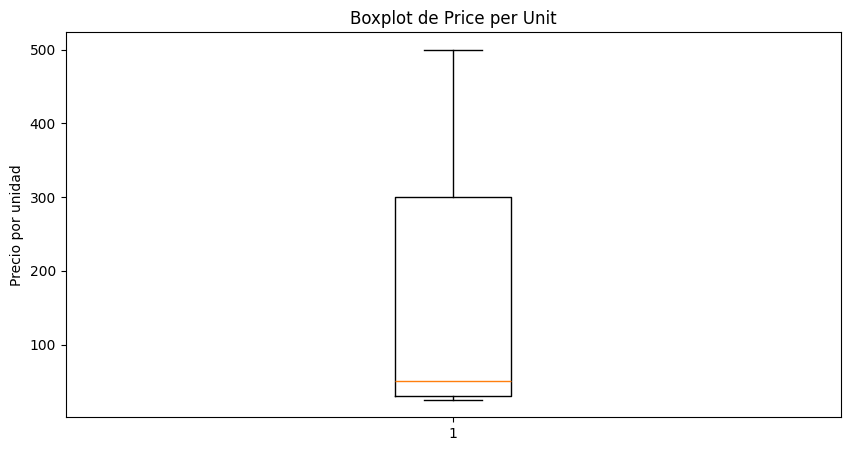

In [ ]:
# __________________________________________
#     Importación de librerías
# __________________________________________

# matplotlib.pyplot se utiliza para crear gráficos.
import matplotlib.pyplot as plt


# __________________________________________
#     Histograma de Total Amount
# __________________________________________

# El histograma permite visualizar cómo se distribuyen los montos totales de venta dentro del dataset.

# bins define la cantidad de divisiones o "bloques"
# que tendrá el histograma.

plt.figure(figsize=(10,5))

plt.hist(
    df['Total Amount'],
    bins=10
)

# Título del gráfico
plt.title('Distribución de Total Amount')

# Nombre eje X
plt.xlabel('Monto total de venta')

# Nombre eje Y
plt.ylabel('Frecuencia')

# Mostrar gráfico
plt.show()


# __________________________________________
#     Boxplot de Total Amount
# __________________________________________

# El boxplot permite observar:
# - mediana
# - dispersión
# - cuartiles
# - posibles valores atípicos (outliers)

plt.figure(figsize=(10,5))

plt.boxplot(df['Total Amount'])

# Título
plt.title('Boxplot de Total Amount')

# Nombre eje Y
plt.ylabel('Monto total de venta')

# Mostrar gráfico
plt.show()


# __________________________________________
#     Histograma de Price per Unit
# __________________________________________

# Este histograma permite visualizar
# cómo se distribuyen los precios unitarios.

plt.figure(figsize=(10,5))

plt.hist(
    df['Price per Unit'],
    bins=10
)

plt.title('Distribución de Price per Unit')

plt.xlabel('Precio por unidad')

plt.ylabel('Frecuencia')

plt.show()


# __________________________________________
#     Boxplot de Price per Unit
# __________________________________________

# Este boxplot permite identificar:
# - dispersión de precios
# - rango intercuartílico
# - posibles precios atípicos

plt.figure(figsize=(10,5))

plt.boxplot(df['Price per Unit'])

plt.title('Boxplot de Price per Unit')

plt.ylabel('Precio por unidad')

plt.show()

**Análisis de la distribución de Total Amount mediante histograma y boxplot**


**1. Distribución de Total Amount**

- El histograma de Total Amount muestra que la mayoría de las ventas se concentran en montos bajos, principalmente por debajo de 250, lo que indica que las compras más frecuentes son de valor pequeño.

- La distribución es sesgada hacia la derecha (right skewed): existen algunos montos mucho más altos, cercanos a 2000, pero con mucha menor frecuencia, lo que sugiere la presencia de ventas poco comunes o transacciones de alto valor (posibles outliers).

**2. Boxplot de Total Amount**

- El boxplot confirma una dispersión importante en los montos de venta: la caja se concentra en valores bajos, mientras que el bigote superior se extiende considerablemente, capturando valores altos.

- La mediana está cerca de la parte inferior de la caja, lo que refuerza que gran parte de las ventas son pequeñas, y unas pocas ventas elevadas aumentan el promedio general, evidenciando asimetría positiva (positive skewness).

**3. Distribución de Price per Unit**

- El histograma de Price per Unit muestra que la mayoría de los productos tienen precios bajos, concentrados entre 25 y 50, lo que indica un catálogo dominado por productos económicos.

- Aparecen también productos con precios mucho más altos (300, 500), aunque con mucha menor frecuencia, lo que evidencia alta dispersión de precios y una clara diferencia entre productos baratos y de mayor valor.

**4. Boxplot de Price per Unit**

- El boxplot de Price per Unit muestra una dispersión considerable entre precios unitarios, con la mediana cerca de valores bajos y muchos valores atípicos hacia arriba.

- Esto indica que el catálogo no se concentra en un solo rango de precios, sino que combina productos económicos con otros de gama alta, reflejado en un rango intercuartílico amplio (wide interquartile range).

**5. Relación general entre histogramas y boxplots**

- Los histogramas permiten observar la forma de la distribución y la frecuencia relativa de los valores, mientras que los boxplots ayudan a identificar la dispersión, la mediana y la presencia de posibles outliers de forma más explícita.

- En conjunto, ambos tipos de gráficos muestran que tanto Total Amount como Price per Unit presentan distribuciones asimétricas (sesgadas a la derecha) y concentradas principalmente en valores bajos, acompañadas de algúnos valores altos menos frecuentes, consistentes con la alta desviación estándar observada en el análisis descriptivo.



**Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.**



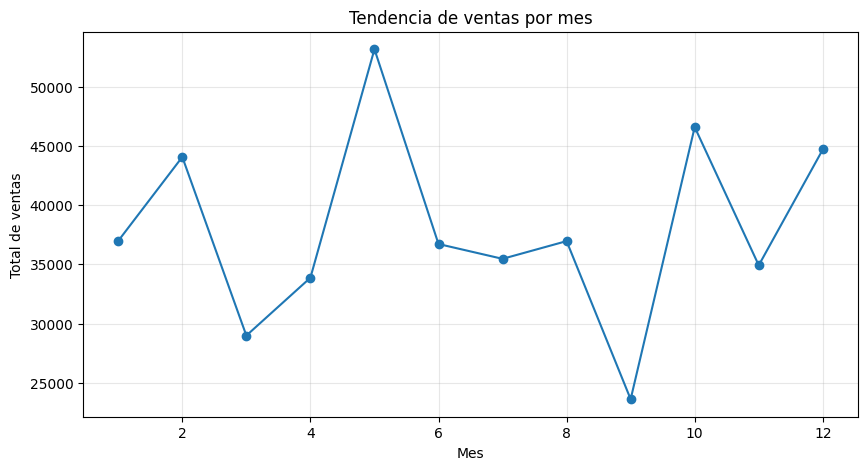

In [ ]:
# __________________________________________
#     Gráfico de líneas de ventas por mes
# __________________________________________

# En esta etapa se utilizará un gráfico de líneas para visualizar cómo cambian las ventas a lo largo del tiempo.

# Para este caso:
# - se agruparán las ventas por mes
# - y luego se calculará la suma total de ventas
#   de cada mes.


# __________________________________________
#     Agrupación de ventas por mes
# __________________________________________

# groupby('Mes') permite agrupar los registros
# según el número de mes.
#
# Posteriormente:
# .sum() calcula el total de ventas mensual.

ventas_por_mes = (
    df.groupby('Mes')['Total Amount']
    .sum()
)


# __________________________________________
#     Visualización de resultados
# __________________________________________

# plt.plot() crea el gráfico de líneas.
#
# Eje X:
# meses del año.
#
# Eje Y:
# total de ventas de cada mes.

plt.figure(figsize=(10,5))

plt.plot(
    ventas_por_mes.index,
    ventas_por_mes.values,
    marker='o'
)

# Título del gráfico
plt.title('Tendencia de ventas por mes')

# Nombre eje X
plt.xlabel('Mes')

# Nombre eje Y
plt.ylabel('Total de ventas')

# Agrega cuadrícula suave para facilitar lectura
plt.grid(True, alpha=0.3)

plt.show()

**Interpretación Gráfico de líneas de ventas por mes**:

- El gráfico de líneas permite observar cómo varían las ventas totales a lo largo de los distintos meses del año. Cada punto representa la suma total de Total Amount para un mes específico, mientras que la línea facilita visualizar la evolución temporal de las ventas.

- En términos generales, las ventas muestran fluctuaciones importantes entre meses, lo que indica que el comportamiento comercial no se mantiene constante durante todo el año.

- El mes 5 presenta el nivel de ventas más alto, superando aproximadamente las 50.000 unidades monetarias. Esto podría sugerir un periodo de alta demanda, campañas promocionales o un aumento temporal en el consumo.

- En contraste, el mes 9 muestra el nivel de ventas más bajo, cercano a 24.000, lo que evidencia una disminución considerable respecto a otros periodos.

- También se observan recuperaciones importantes después de meses bajos.

- Por ejemplo, tras la caída del mes 9, las ventas aumentan de forma significativa en el mes 10, lo que muestra un cambio brusco en la tendencia.
Desde el punto de vista estadístico, el gráfico evidencia variabilidad temporal en las ventas, ya que existen diferencias relevantes entre los máximos y mínimos mensuales.

- En términos de negocio, este tipo de análisis puede ayudar a identificar posibles patrones estacionales (seasonality), meses de alto rendimiento y periodos de menor actividad comercial.

- Esta información resulta útil para la planificación de inventario, campañas de marketing y proyecciones futuras de ventas.

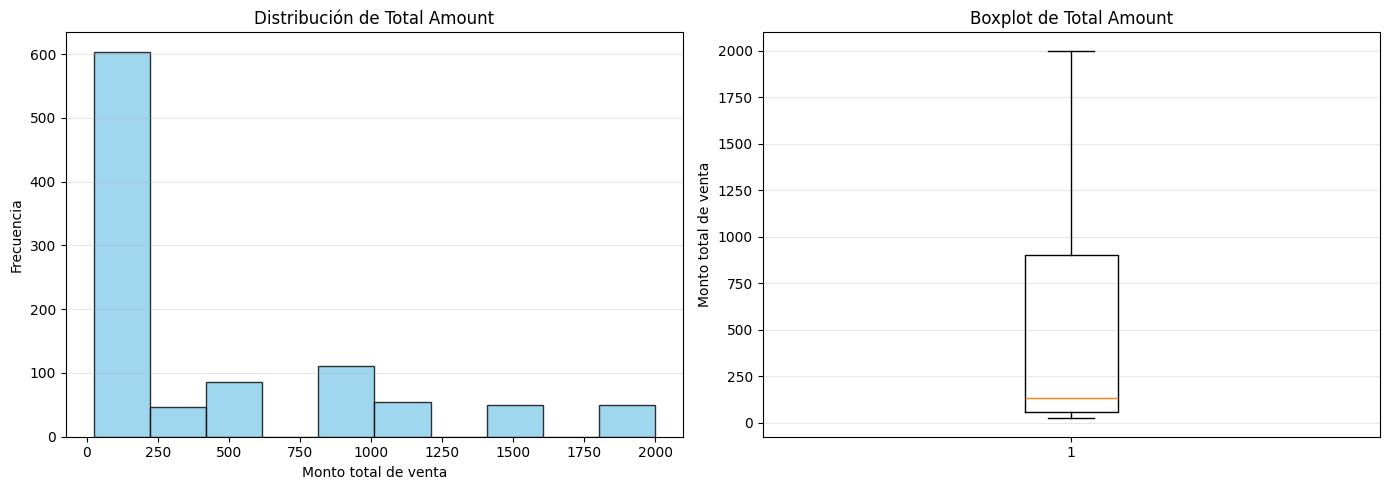

In [ ]:
# __________________________________________
# Histograma y boxplot de Total Amount
# __________________________________________

# Se utilizan subplots para mostrar ambas visualizaciones en una misma figura.

# El histograma permite observar:
# - distribución
# - frecuencia
# - concentración de valores

# El boxplot permite identificar:
# - mediana
# - dispersión
# - posibles valores atípicos (outliers)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))


# __________________________________________
# Histograma
# __________________________________________

ax[0].hist(
    df["Total Amount"],
    bins=10,
    color="skyblue",
    edgecolor="black",
    alpha=0.8
)

ax[0].set_title("Distribución de Total Amount")

ax[0].set_xlabel("Monto total de venta")

ax[0].set_ylabel("Frecuencia")

ax[0].grid(True, axis="y", alpha=0.3)


# __________________________________________
# Boxplot
# __________________________________________

ax[1].boxplot(
    df["Total Amount"],
    vert=True
)

ax[1].set_title("Boxplot de Total Amount")

ax[1].set_ylabel("Monto total de venta")

ax[1].grid(True, axis="y", alpha=0.3)


# Ajusta automáticamente los espacios entre ambos gráficos.
plt.tight_layout()

plt.show()

**Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.**

- Para esta sección se eligieron las columnas Quantity y Total Amount porque permiten explorar si la cantidad de productos comprados influye en el valor final de la venta.

- Esta comparación es útil en retail, ya que ayuda a identificar si las transacciones de mayor volumen generan montos más altos.

- Aunque la relación entre ambas variables no necesariamente será lineal, el gráfico de dispersión facilita observar patrones de concentración, dispersión y posibles valores atípicos.


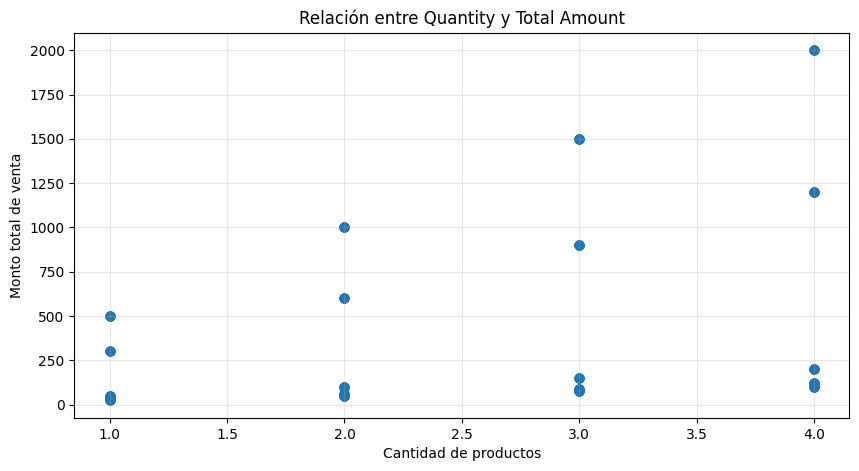

In [ ]:
# __________________________________________
#     Scatterplot Quantity vs Total Amount
# __________________________________________

# alpha=0.5 agrega transparencia a los puntos
# para visualizar mejor zonas donde existen
# muchos datos superpuestos.

# grid() agrega una cuadrícula suave
# para facilitar la lectura visual del gráfico.

plt.figure(figsize=(10, 5))

plt.scatter(
    df["Quantity"],
    df["Total Amount"],
    alpha=0.5
)

plt.title("Relación entre Quantity y Total Amount")
plt.xlabel("Cantidad de productos")
plt.ylabel("Monto total de venta")
plt.grid(True, alpha=0.3)
plt.show()

**Hallazgos del gráfico de dispersión**

- El gráfico de dispersión entre Quantity y Total Amount permite observar cómo cambia el monto total de una venta según la cantidad de productos comprados. En términos generales, se aprecia que cuando un cliente compra más productos, el valor total de la compra tiende a aumentar.

- Esto sugiere una posible relación positiva entre ambas variables, es decir, una posible correlación positiva.
Sin embargo, la relación no es perfectamente directa ni lineal. Para una misma cantidad de productos, los montos de venta pueden ser muy distintos. Por ejemplo, hay compras de 2 productos con valores bajos, pero también aparecen otras con montos bastante más altos.

- Esto indica que la cantidad comprada no explica por sí sola el valor final de la transacción.

- La razón principal es que el monto total también depende del precio de cada producto. En otras palabras, no solo importa cuántos artículos se compran, sino también cuánto cuesta cada uno. Por eso, dos ventas con la misma cantidad de productos pueden terminar con montos muy diferentes.

- Además, se observa que la dispersión de los datos aumenta cuando crece la cantidad comprada. En el caso de Quantity = 4, aparecen tanto ventas pequeñas como ventas muy altas, incluso cercanas a 2000. Esto muestra que, a mayor cantidad de productos, también crece la variabilidad del monto total.

- El gráfico también permite identificar posibles valores atípicos, es decir, transacciones con montos mucho más altos que la mayoría de los registros. Estas observaciones pueden corresponder a compras excepcionales o a productos de alto valor.

- En resumen, el análisis muestra que el monto total de una venta no depende únicamente de la cantidad de productos comprados, sino también del precio unitario de los artículos incluidos en cada transacción.

- Desde el punto de vista estadístico, esto refleja una posible relación positiva, pero con alta dispersión y presencia de posibles outliers.

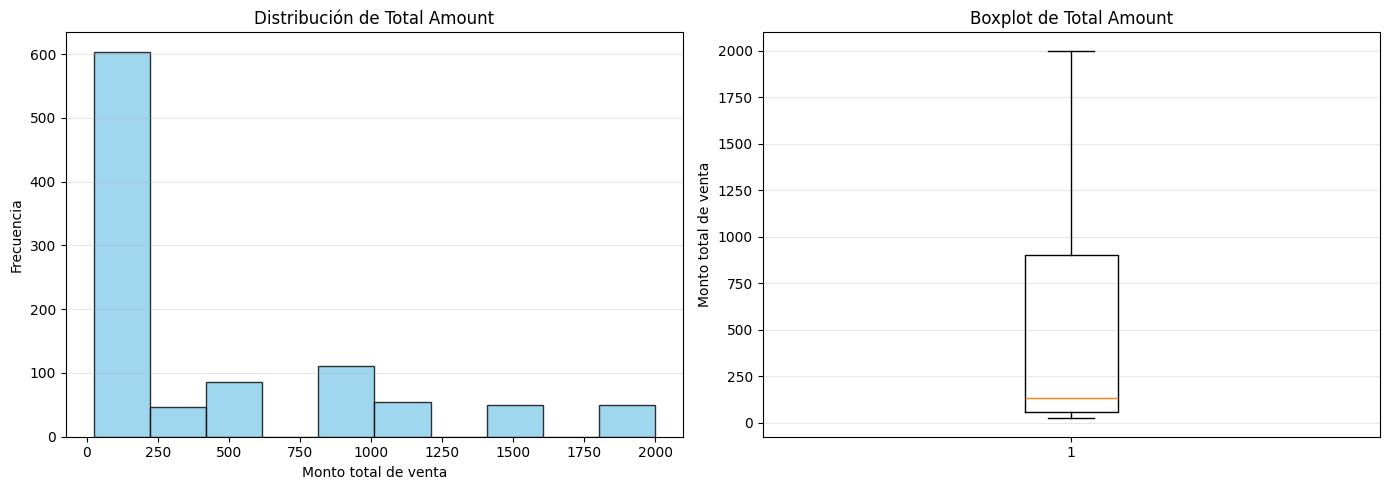

In [ ]:
# __________________________________________
# Histograma y boxplot de Total Amount
# __________________________________________

# Se utilizan subplots para mostrar ambas visualizaciones en una misma figura.

# El histograma permite observar:
# - distribución
# - frecuencia
# - concentración de valores

# El boxplot permite identificar:
# - mediana
# - dispersión
# - posibles valores atípicos (outliers)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))


# __________________________________________
# Histograma
# __________________________________________

ax[0].hist(
    df["Total Amount"],
    bins=10,
    color="skyblue",
    edgecolor="black",
    alpha=0.8
)

ax[0].set_title("Distribución de Total Amount")

ax[0].set_xlabel("Monto total de venta")

ax[0].set_ylabel("Frecuencia")

ax[0].grid(True, axis="y", alpha=0.3)


# __________________________________________
# Boxplot
# __________________________________________

ax[1].boxplot(
    df["Total Amount"],
    vert=True
)

ax[1].set_title("Boxplot de Total Amount")

ax[1].set_ylabel("Monto total de venta")

ax[1].grid(True, axis="y", alpha=0.3)


# Ajusta automáticamente los espacios
# entre ambos gráficos.
plt.tight_layout()

plt.show()

**Interpretación del histograma y boxplot de Total Amount**

- La combinación entre histograma y boxplot permite analizar la distribución de Total Amount desde dos perspectivas complementarias.

- El histograma muestra que la mayoría de las ventas se concentra en montos bajos, especialmente por debajo de 250, lo que indica que las transacciones pequeñas son las más frecuentes dentro del dataset.

- A medida que aumenta el monto de venta, la frecuencia disminuye considerablemente, y aparecen pocas ventas en rangos altos, cercanas a 1500 y 2000. Esto genera una distribución asimétrica hacia la derecha (right skewed distribution).

- El boxplot refuerza esta interpretación al mostrar una mediana baja y un bigote superior bastante extendido, lo que evidencia una dispersión importante y una asimetría positiva (positive skewness).

- En conjunto, ambos gráficos permiten identificar posibles valores atípicos (outliers) y muestran que la tienda realiza principalmente ventas pequeñas o medianas, aunque ocasionalmente ocurren compras de alto valor que incrementan significativamente el promedio general.


**Parte V: Exploración y Visualización de Datos Avanzada**

- En esta quinta parte del proyecto, vamos a expandir nuestro análisis exploratorio de datos (EDA) y visualización utilizando técnicas avanzadas.
> Aplicaremos todo lo que hemos aprendido hasta ahora, incluyendo cuadrículas, leyendas, anotaciones, flechas, y subplots, para obtener una comprensión más profunda de nuestro conjunto de datos de ventas.

**1. Análisis de correlación + heatmap**

En esta sección se realizará un análisis de correlación entre las variables numéricas del dataset.

La correlación permite medir el nivel de relación entre dos variables y ayuda a entender si, cuando una cambia, la otra también tiende a aumentar, disminuir o mantenerse sin una relación clara.

Posteriormente, se utilizará un mapa de calor (heatmap) para visualizar de forma sencilla la intensidad de estas relaciones, facilitando su comprensión.

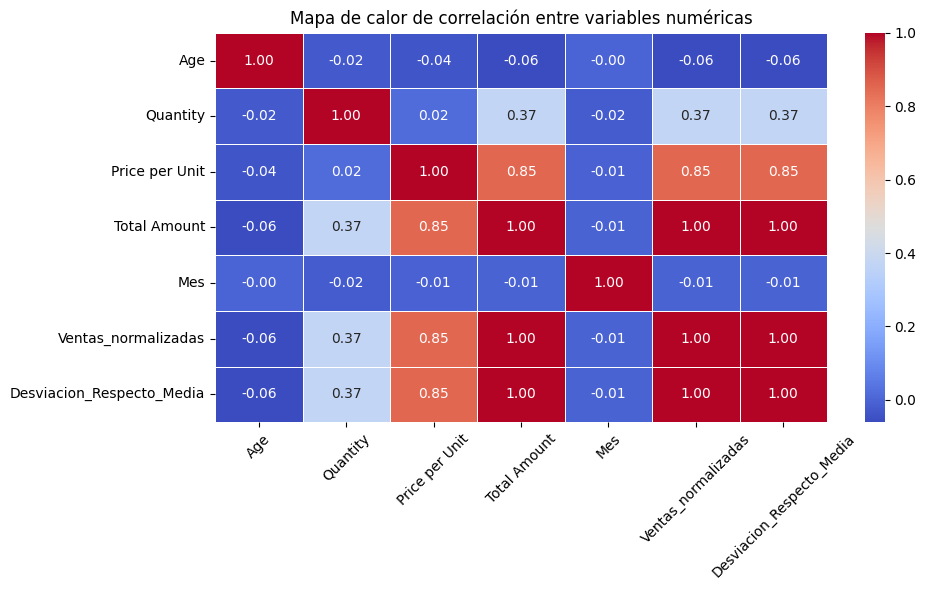

In [ ]:
# __________________________________________
# Análisis de correlación y heatmap
# __________________________________________

# Se importan las librerías necesarias para graficar.
# Matplotlib se usa para personalizar la figura.
# Seaborn se usa para crear el mapa de calor de forma más sencilla y visual.
import matplotlib.pyplot as plt
import seaborn as sns

# Se seleccionan solo las variables numéricas que serán analizadas.
# Estas columnas son útiles porque permiten comparar montos, cantidades,
# edad y variables creadas en el proceso de transformación.
columnas_corr = [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount',
    'Mes',
    'Ventas_normalizadas',
    'Desviacion_Respecto_Media'
]

# Se calcula la matriz de correlación entre todas las variables elegidas.
# El resultado muestra qué tan relacionadas están entre sí.
# Valores cercanos a 1 indican relación positiva fuerte,
# valores cercanos a -1 indican relación negativa fuerte,
# y valores cercanos a 0 indican poca o ninguna relación lineal.
corr = df[columnas_corr].corr()

# Se define el tamaño de la figura para que el gráfico sea legible.
plt.figure(figsize=(10, 6))

# Se crea el mapa de calor.
# annot=True muestra los valores dentro de cada celda.
# fmt='.2f' redondea los valores a dos decimales.
# cmap='coolwarm' usa una escala de colores para diferenciar correlaciones altas y bajas.
# linewidths y linecolor ayudan a separar visualmente cada celda.
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white'
)

# Se agrega un título para explicar de qué trata el gráfico.
plt.title('Mapa de calor de correlación entre variables numéricas')

# Se rota el texto del eje X para que los nombres de las variables no se superpongan.
plt.xticks(rotation=45)

# Se mantiene el texto del eje Y en posición horizontal para facilitar la lectura.
plt.yticks(rotation=0)

# Se ajusta el espacio automáticamente para que no se corten etiquetas ni títulos.
plt.tight_layout()

# Finalmente, se muestra el gráfico.
plt.show()

El mapa de calor muestra varias relaciones interesantes entre las variables numéricas del dataset.

>En general, el gráfico está correctamente construido, ya que utiliza variables relevantes, etiquetas legibles y una escala de colores que permite identificar fácilmente las correlaciones más fuertes y más débiles entre las variables.

**1. Price per Unit y Total Amount**

- La correlación entre Price per Unit y Total Amount es fuerte y positiva, cercana a 0.85. Esto significa que, a medida que aumenta el precio unitario de los productos, el monto total de la venta también tiende a aumentar.

- Desde el punto de vista del negocio, este comportamiento es esperable, ya que los productos con mayor valor unitario generan ventas totales más elevadas.

**2. Quantity y Total Amount**

- La relación entre Quantity y Total Amount es positiva y moderada, alrededor de 0.37. Esto indica que la cantidad comprada sí influye en el monto final de la venta, aunque en menor medida que el precio unitario.

Además, esta observación coincide con el análisis realizado previamente en el scatterplot, por lo que ambas visualizaciones se complementan y refuerzan la interpretación de los datos.

3. Age y el resto de variables

- La variable Age presenta correlaciones muy cercanas a 0 con las demás variables numéricas. Por ejemplo, su relación con Quantity y Total Amount es prácticamente nula.

- Esto sugiere que, dentro de este dataset, la edad de los clientes no parece tener una influencia lineal importante sobre la cantidad comprada, el monto total de compra ni el precio de los productos adquiridos.

**4. Mes y las variables de venta**

- La variable Mes también muestra correlaciones débiles con el resto de las variables numéricas. Esto indica que no se observa una relación lineal fuerte entre el mes y el comportamiento de compra.

- Sin embargo, esto no significa necesariamente que no existan patrones temporales, sino que dichos patrones no se representan claramente mediante correlaciones lineales dentro de esta matriz.

**5. Variables derivadas y correlaciones perfectas**

- Las variables Ventas_normalizadas y Desviacion_Respecto_Media presentan correlaciones extremadamente altas con Total Amount.

- Esto ocurre porque ambas variables fueron construidas directamente a partir de Total Amount, por lo que no son variables independientes. Desde el punto de vista estadístico, este comportamiento es completamente esperable y valida que las transformaciones fueron realizadas correctamente.

**Conclusión general**

- En resumen, el heatmap permite identificar que Price per Unit es la variable con mayor relación respecto a Total Amount, mientras que Quantity presenta una influencia moderada.

- Por otro lado, variables como Age y Mes no muestran relaciones lineales relevantes dentro del dataset. Finalmente, las variables derivadas reflejan coherentemente su origen matemático, lo que confirma la consistencia de la transformación de datos realizada durante el análisis.

**2. Subplots para comparación de variables clave**

- En esta sección se utilizarán subplots para visualizar distintas variables relevantes del dataset dentro de una misma figura.

- El uso de subplots permite comparar múltiples gráficos de manera simultánea, facilitando la identificación de patrones, distribuciones, tendencias y relaciones entre variables.

- Para este análisis se incluirán histogramas, boxplots, gráficos de dispersión y gráficos de líneas, utilizando algunas de las variables más importantes del dataset de ventas.

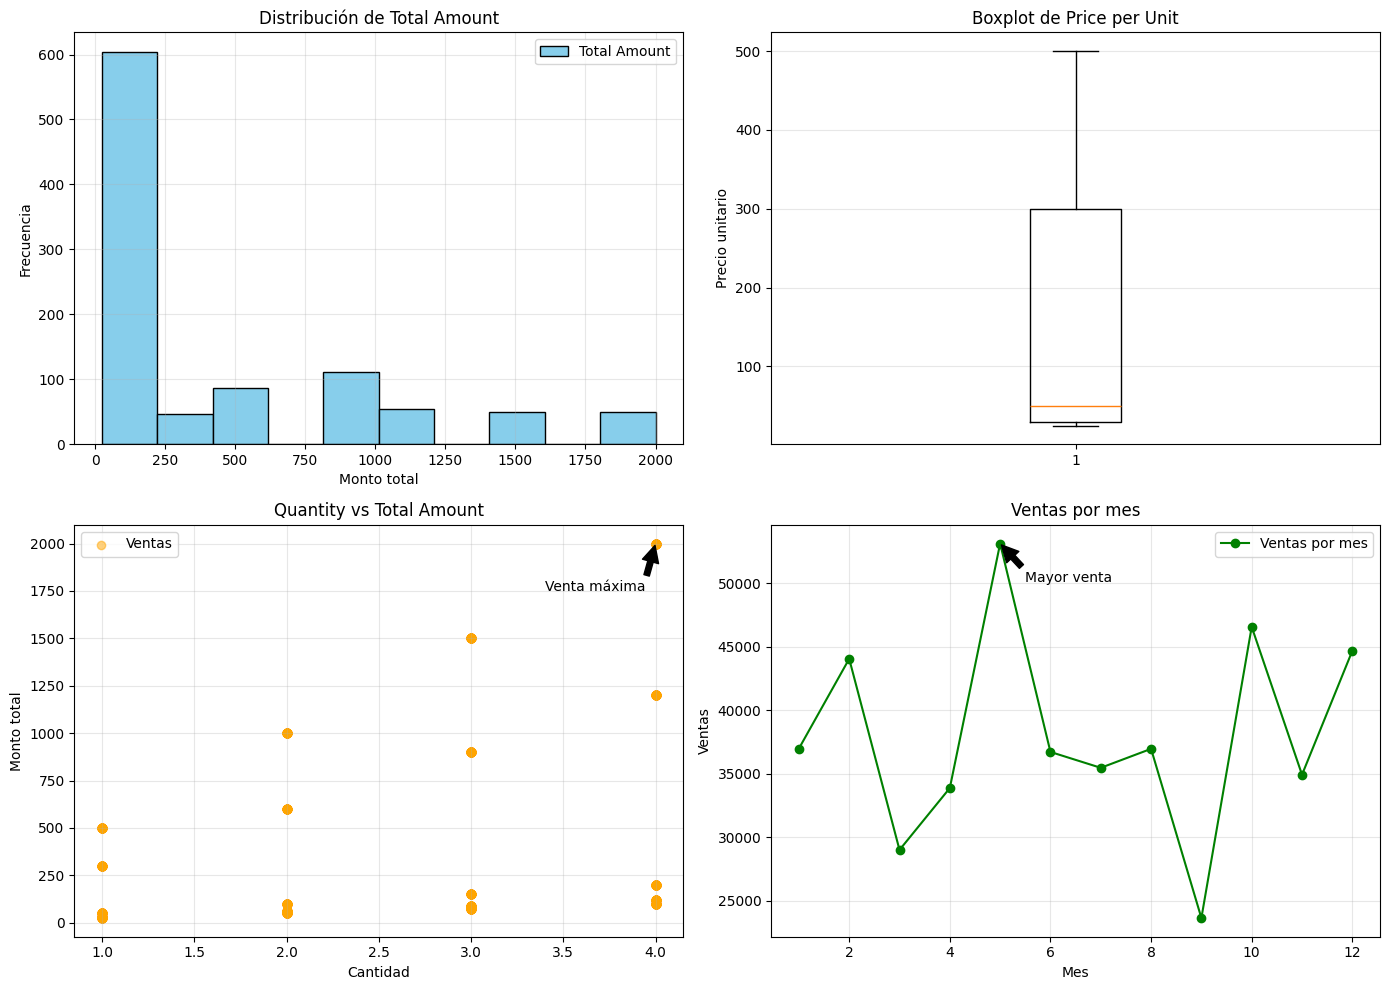

In [ ]:
# __________________________________________
# Subplots para comparación de variables
# __________________________________________

# Se crea una figura con 4 gráficos distribuidos en una matriz de 2 filas y 2 columnas.
# Esta estructura permite comparar varias variables clave en una sola vista.
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# --------------------------------------------------
# 1. Histograma de Total Amount
# --------------------------------------------------
# Este gráfico muestra cómo se distribuyen los montos totales de venta.
# Permite ver si la mayoría de los valores se concentran en rangos bajos, medios o altos.
ax[0, 0].hist(
    df['Total Amount'],
    bins=10,
    color='skyblue',
    edgecolor='black',
    label='Total Amount'
)
ax[0, 0].set_title('Distribución de Total Amount')
ax[0, 0].set_xlabel('Monto total')
ax[0, 0].set_ylabel('Frecuencia')
ax[0, 0].grid(True, alpha=0.3)
ax[0, 0].legend()

# --------------------------------------------------
# 2. Boxplot de Price per Unit
# --------------------------------------------------
# El boxplot permite observar la mediana, la dispersión y posibles valores atípicos.
# En este caso se utiliza para analizar el comportamiento del precio unitario.
ax[0, 1].boxplot(df['Price per Unit'])
ax[0, 1].set_title('Boxplot de Price per Unit')
ax[0, 1].set_ylabel('Precio unitario')
ax[0, 1].grid(True, axis='y', alpha=0.3)

# --------------------------------------------------
# 3. Scatterplot entre Quantity y Total Amount
# --------------------------------------------------
# Este gráfico ayuda a observar si existe una relación entre la cantidad comprada
# y el monto total de la venta.
ax[1, 0].scatter(
    df['Quantity'],
    df['Total Amount'],
    alpha=0.5,
    color='orange',
    label='Ventas'
)
ax[1, 0].set_title('Quantity vs Total Amount')
ax[1, 0].set_xlabel('Cantidad')
ax[1, 0].set_ylabel('Monto total')
ax[1, 0].grid(True, alpha=0.3)
ax[1, 0].legend()

# Anotación de la venta máxima
idx_max = df['Total Amount'].idxmax()
x_max = df.loc[idx_max, 'Quantity']
y_max = df.loc[idx_max, 'Total Amount']

ax[1, 0].annotate(
    'Venta máxima',
    xy=(x_max, y_max),
    xytext=(x_max - 0.6, y_max - 250),
    arrowprops=dict(facecolor='black', shrink=0.05),
    fontsize=10
)

# --------------------------------------------------
# 4. Línea de ventas por mes
# --------------------------------------------------
# Este gráfico muestra la evolución de las ventas a lo largo del tiempo.
# Sirve para identificar meses con mayores o menores montos vendidos.
ax[1, 1].plot(
    ventas_por_mes.index,
    ventas_por_mes.values,
    marker='o',
    color='green',
    label='Ventas por mes'
)
ax[1, 1].set_title('Ventas por mes')
ax[1, 1].set_xlabel('Mes')
ax[1, 1].set_ylabel('Ventas')
ax[1, 1].grid(True, alpha=0.3)
ax[1, 1].legend()

# Anotación del mes con mayores ventas
mes_max = ventas_por_mes.idxmax()
valor_max = ventas_por_mes.max()

ax[1, 1].annotate(
    'Mayor venta',
    xy=(mes_max, valor_max),
    xytext=(mes_max + 0.5, valor_max - 3000),
    arrowprops=dict(facecolor='black', shrink=0.05),
    fontsize=10
)

# Se ajustan los espacios para que los gráficos no se monten entre sí.
plt.tight_layout()
plt.show()

**Interpretación de los subplots**

- La figura reúne cuatro visualizaciones distintas que permiten comparar variables clave del dataset desde perspectivas complementarias. En conjunto, los gráficos muestran cómo se distribuyen los montos de venta, cómo varía el precio unitario, cómo se relacionan la cantidad y el monto total, y cómo cambian las ventas a lo largo de los meses.

**1. Distribución de Total Amount**

El histograma muestra que la mayoría de las ventas se concentra en montos bajos, especialmente por debajo de 250. Esto indica que las transacciones más frecuentes son de menor valor, mientras que los montos altos aparecen con menor frecuencia.

También se observa una cola hacia la derecha, lo que sugiere asimetría positiva en la distribución. Este patrón coincide con el análisis descriptivo previo, donde ya se había visto que existen pocos valores muy altos que elevan la dispersión general del dataset.

**2. Boxplot de Price per Unit**

El boxplot muestra que el precio unitario tiene una dispersión amplia. La mediana se encuentra en valores bajos, pero el rango superior se extiende bastante, lo que indica que el catálogo combina productos económicos con otros de mayor valor.

Esta representación también ayuda a identificar posibles valores atípicos en la parte alta de la distribución. Desde el punto de vista del negocio, esto confirma que no existe un único rango de precios dominante, sino una mezcla de productos de distintos niveles de valor.

**3. Quantity vs Total Amount**

El scatterplot muestra una relación positiva entre cantidad comprada y monto total, pero no es perfecta. Se observa que, para una misma cantidad, los montos pueden variar bastante, lo que significa que el precio unitario también influye fuertemente en el valor final de la venta.

La anotación de la venta máxima resalta precisamente ese punto más alto del gráfico, permitiendo identificar visualmente una transacción que destaca sobre el resto. Esto ayuda a interpretar mejor los posibles valores extremos y conecta con el análisis de correlación realizado antes.

**4. Ventas por mes**

El gráfico de línea muestra que las ventas mensuales no siguen una tendencia lineal constante. Hay meses con valores altos, como el mes 5, y también meses con caídas importantes, como el mes 9, lo que sugiere variabilidad temporal en el comportamiento de compra.

La flecha que marca el punto de mayor venta facilita identificar rápidamente el mes con el pico más alto. Este tipo de anotación mejora la lectura del gráfico y hace más evidente qué periodo destaca dentro del año analizado.

**Lectura conjunta**

En conjunto, los cuatro subplots permiten entender el dataset desde distintas perspectivas. El histograma y el boxplot describen la forma y dispersión de las variables, mientras que el scatterplot y la línea temporal ayudan a ver relaciones y patrones de comportamiento.

Además, las anotaciones y flechas agregan un valor explicativo importante porque llaman la atención sobre los puntos más relevantes del análisis. Eso hace que la visualización no sea solo decorativa, sino una herramienta real de interpretación estadística.

**Conclusión**

La figura confirma que las ventas tienden a concentrarse en montos bajos, que el precio unitario tiene una dispersión importante, que la cantidad influye en el monto total pero no de forma absoluta, y que existen meses con picos claros de actividad comercial.

En conjunto, los resultados del análisis exploratorio y de las visualizaciones permiten identificar oportunidades de mejora relacionadas con las promociones y la planificación de inventario.

 La concentración de las ventas en montos bajos sugiere que podrían implementarse estrategias orientadas a aumentar el valor promedio de compra, mientras que la variabilidad observada en las ventas mensuales indica que una mejor gestión del inventario podría ayudar a responder con mayor eficiencia a los cambios en la demanda.

 Además, el análisis mostró que el precio unitario tiene una influencia importante sobre el monto total de venta, por lo que las transacciones asociadas a precios más altos podrían representar una oportunidad relevante para fortalecer los ingresos del negocio.”